# Multi-Fidelity SCBO Optimization on Hartmann6 Function
This notebook demonstrates how to run a multi-fidelity SCBO optimization using the `mfscbo` package on the Hartmann6 benchmark function.

In [1]:
# Import necessary libraries
from mfscbo.functions import Hartmann6
from mfscbo.mfscbo_optimization import ScboMfOptimizer
from mfscbo.plot import plot_rhos, plot_noises, plot_bestYs, plot_nbiters, plot_tr_lengths
from mfscbo.utils import eval_fun_unnormalized
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

/home/lpalazzo/Documents/These/BayesianOC/matlab_env_boc/lib64/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Define torch arguments
torchargs = {
    "device": "cpu",
    "dtype": torch.double
}

In [3]:
# Define evaluation objectives at different fidelities
f0_ = Hartmann6(fidelity=1, fidelity_high=3, torchargs=torchargs)
f1_ = Hartmann6(fidelity=2, fidelity_high=3, torchargs=torchargs)
f2_ = Hartmann6(fidelity=3, fidelity_high=3, torchargs=torchargs)

# Define bounds and dimension
bounds = f0_.bounds
dim = bounds.shape[1]

# Convert to maximization problem (SCBO expects maximization) and unnormalize
f0 = lambda x: -eval_fun_unnormalized(x, f0_, bounds)
f1 = lambda x: -eval_fun_unnormalized(x, f1_, bounds)
f2 = lambda x: -eval_fun_unnormalized(x, f2_, bounds)
eval_objectives = [f0, f1, f2]

In [4]:
# Define constraints
r_constraint = 0.4
center_constraint = torch.tensor([0.20169, 0.150011, 0.476874, 0.275332, 0.311652, 0.6573], **torchargs)
constraints = lambda x: torch.sum((x - center_constraint)**2, dim=1, keepdim=True) - r_constraint**2

In [5]:
# Define number of initial points, rhos, and costs for each fidelity
n_pts = [12, 9, 3]  # total 4*dim = 12+9+3
rhos = [1, 1, 1]
costs = [1, 10, 20]

In [6]:
# Initialize and run the SCBO optimizer
optimizer = ScboMfOptimizer(
    eval_objectives=eval_objectives,
    constraints=constraints,
    rhos=rhos,
    costs=costs,
    dim=dim,
    n_pts=n_pts,
    bounds=bounds,
    type_of_batch="sequential",
    type_of_centering="evaluated",
    torchargs=torchargs,
    restart=True,
    test=True,  # Predictive mode
)
optimizer.initialize()
optimizer.optimize(max_cost=2000, batch_size=8, path="results/Hartmann6", verbose=True)

Starting MF-SCBO optimization...
Max cost : 2000
Batch size : 8
Path : results/Hartmann6

========================= Parameters for MF-SCBO Optimization ==========================
________________________________________________________________________________________
| Parameter         | Value                                                            |
----------------------------------------------------------------------------------------
| dim               | 6                                                                |
| bounds            | [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]] |
| nb_fidelities     | 3                                                                |
| n_pts             | [12, 9, 3]                                                       |
| rhos              | [1, 1, 1]                                                        |
| costs             | [1, 10, 20]                                                      |
| type_of_batch     

In [7]:
# Load results
data = np.load("results/Hartmann6/MFSCBO_data.npz", allow_pickle=True)
gps_info = data["gps_info"]
iterations = data["iterations"]
xvalues = data["cost_iter"]
bestY = data["best_Y"]
nbiters = data["nb_iter"]
tr_lengths = data["trust_region_lengths"]

In [8]:
# Post-process rhos
rhos = [[1] for _ in range(len(gps_info)-1)]  # no rho for fidelity 0
for fid in range(1, len(gps_info)):
    for it in range(len(iterations)-1):
        rhos[fid-1].append(gps_info[fid][it]["rho"])

# Post-process noises
noises = [[] for _ in range(len(gps_info))]
for fid in range(len(gps_info)):
    for it in range(len(iterations)-1):
        noises[fid].append(gps_info[fid][it]["noise"])

/tmp/ipykernel_2393077/345971927.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax5.legend()


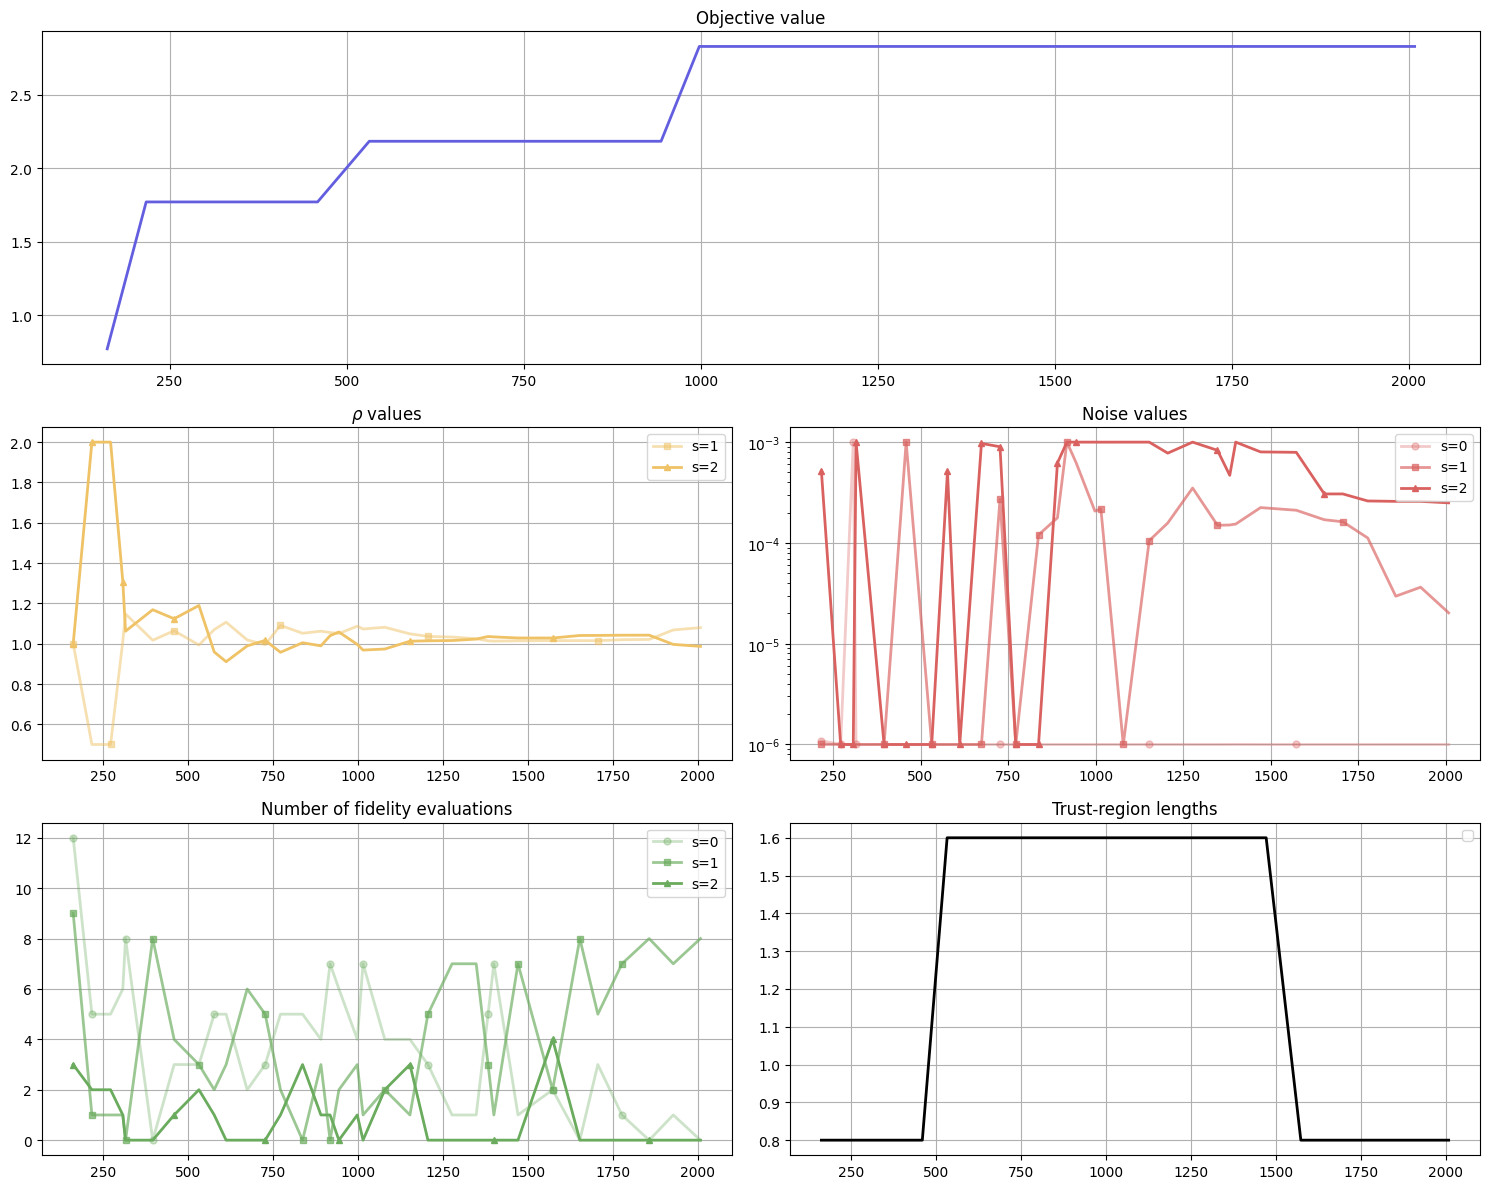

In [9]:
# Plot results
fig = plt.figure(figsize=(15, 12))
gs = GridSpec(3, 2, figure=fig)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])
ax4 = fig.add_subplot(gs[2, 0])
ax5 = fig.add_subplot(gs[2, 1])

plot_bestYs(bestY, xvalues, ax=ax1)
plot_rhos(rhos, xvalues, ax=ax2)
plot_noises(noises, xvalues[1:], ax=ax3)
plot_nbiters(nbiters, xvalues, ax=ax4)
plot_tr_lengths(tr_lengths, xvalues, ax=ax5)

# Set titles, legends, and grids
ax1.set_title("Objective value")
ax1.grid()
ax2.set_title(r"$\rho$ values")
ax2.legend()
ax2.grid()
ax3.set_title("Noise values")
ax3.legend()
ax3.grid()
ax3.set_yscale("log")
ax4.set_title("Number of fidelity evaluations")
ax4.legend()
ax4.grid()
ax5.set_title("Trust-region lengths")
ax5.legend()
ax5.grid()

plt.tight_layout()
plt.savefig("results/Hartmann6/MFSCBO_plots.pdf")
plt.show()